In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

import sys
import os
sys.path.insert(0, os.path.abspath('..'))


In [54]:
from src.data_loader import load_data, remove_nulls
print('Functions imported successfully!')
df = load_data("../data/raw/raw_analyst_ratings.csv")
df.head()

Functions imported successfully!


KeyError: 'Date'

# Data Loading

In [3]:
# Load CSV
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

In [35]:
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    errors='coerce',
    utc=True
)
# remove missing dates
df = df.dropna(subset=['date'])

# Data Cleaning

In [4]:
benzinga_variants = df[
    df['publisher'].str.contains('Benzinga', na=False)
]['publisher'].unique()

print(benzinga_variants)

<StringArray>
[             'Benzinga Insights',              'Benzinga Newsdesk',
              'Benzinga_Newsdesk',             'Benzinga  Newsdesk',
               'Benzinga Newdesk',             'Benzinga News Desk',
          'Benzinga Staff Writer',                 'BenzingaStaffJ',
                 'BenzingaStaffL',                 'Benzinga Staff',
                 'BenzingaStaffB',                 'BenzingaStaff3',
                 'BenzingaStaff1',              'Benzinga Newsdesk',
                 'BenzingaStaffT',               'Benzinga Staff 5',
               'Benzinga Staff15',          'Benzinga Pro Newsdesk',
                 'BenzingaStaffK',              'Benzinga Cannabis',
                'Benzinga Events', 'Benzinga Cannabis Contributors',
                 'BenzingaStaff2']
Length: 23, dtype: str


In [5]:
publisher_mapping = {
    'Benzinga Newdesk': 'Benzinga Newsdesk',
    'Benzinga Newsdesk': 'Benzinga Newsdesk',
    'Benzinga Newsdesk': 'Benzinga Newsdesk',
    'Benzinga News Desk': 'Benzinga Newsdesk',
    'Benzinga_Newsdesk': 'Benzinga Newsdesk',
    'Benzinga Pro Newsdesk': 'Benzinga Newsdesk',
    'Benzinga  Newsdesk': 'Benzinga Newsdesk',
    'BenzingaStaff': 'Benzinga Staff',
    'BenzingaStaffB': 'Benzinga Staff',
    'BenzingaStaffJ': 'Benzinga Staff',
    'BenzingaStaffK': 'Benzinga Staff',
    'BenzingaStaffL': 'Benzinga Staff',
    'BenzingaStaffT': 'Benzinga Staff',
    'BenzingaStaff3': 'Benzinga Staff',
    'Benzinga Staff 5': 'Benzinga Staff',
    'Benzinga Staff15': 'Benzinga Staff',
    'BenzingaStaff2': 'Benzinga Staff',
    'BenzingaStaff1': 'Benzinga Staff',
    'Benzinga Staff Writer': 'Benzinga Staff',
   

    'Benzinga Cannabis Contributors': 'Benzinga Cannabis'
}

df['publisher_clean'] = df['publisher'].replace(publisher_mapping)

In [6]:
# lowercase everything
df['publisher_clean'] = df['publisher_clean'].str.lower()

# replace underscores and hyphens with spaces
df['publisher_clean'] = df['publisher_clean'].str.replace(r'[_\-]+', ' ', regex=True)

# remove encoding artifacts
df['publisher_clean'] = df['publisher_clean'].str.replace('â€™', "'", regex=False)
df['publisher_clean'] = df['publisher_clean'].str.replace('â€', ' ', regex=False)
df['publisher_clean'] = df['publisher_clean'].str.replace('â€‰', ' ', regex=False)

# # remove emails
# df['publisher_clean'] = df['publisher_clean'].str.replace(
#     r'\S+@\S+',
#     '',
#     regex=True
# )

# # keep only letters and spaces
# df['publisher_clean'] = df['publisher_clean'].str.replace(
#     r'[^a-z\s]',
#     '',
#     regex=True
# )

# remove extra spaces
df['publisher_clean'] = df['publisher_clean'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

# df['publisher_clean'] = df['publisher_clean'].replace(
#     to_replace=r'.*@benzinga\.com',
#     value='Benzinga Staff',
#     regex=True
# )
df['publisher_clean'] = df['publisher_clean'].str.replace(
    r'.*@benzinga\.com',
    'Benzinga Staff',
    regex=True
)


# Checking for Duplicates and Missing values


In [7]:
# dup_count = df.duplicated().sum()
dup_count = df.duplicated().sum()
print("Number of duplicate rows:", dup_count)
duplicates = df[df.duplicated(keep=False)]
print(duplicates)
print("\nMissing Values:")
display(df.isna().sum())

Number of duplicate rows: 0
Empty DataFrame
Columns: [Unnamed: 0, headline, url, publisher, date, stock, publisher_clean]
Index: []

Missing Values:


Unnamed: 0         0
headline           0
url                0
publisher          0
date               0
stock              0
publisher_clean    0
dtype: int64

# Descriptive Statistics
## Headline Character Count
Headline character count distribution refers to the spread or pattern of headline lengths based on the number of characters they contain.

If most headlines fall between 40–80 characters, it can concluded that they are generally medium-length, with a few very long analytical headlines.

If there are extreme long headlines, they may represent:

    -analyst reports
    -earnings summaries
    -detailed market commentary

Short headlines may represent:

    -alerts
    -stock movers
    -quick updates

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_char_count, dtype: float64


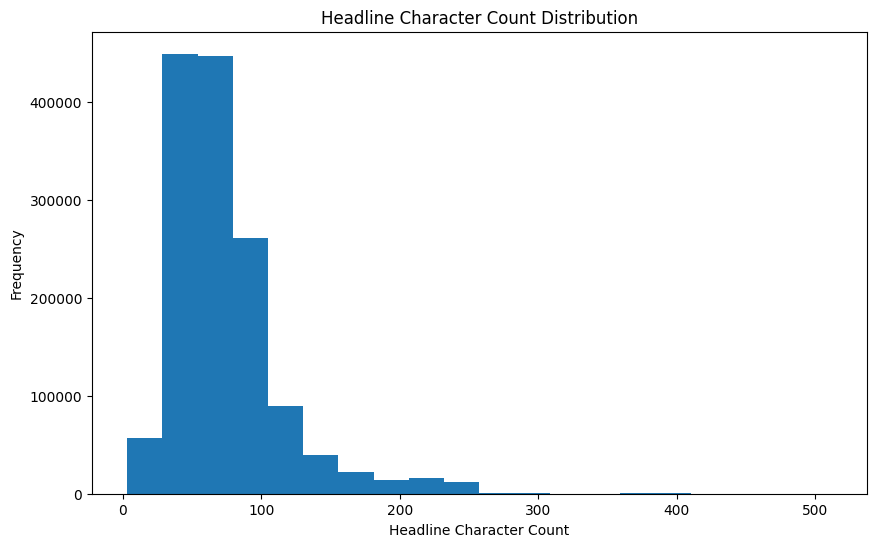

,Unnamed: 0,headline,url,publisher,date,stock,publisher_clean,headline_char_count
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,benzinga insights,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,benzinga insights,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,lisa levin,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,lisa levin,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,vick meyer,87


In [8]:

# Create character count column
df['headline_char_count'] = df['headline'].str.len()


# Summary statistics
print(df['headline_char_count'].describe())
# Plot distribution
plt.figure(figsize=(10,6))
plt.hist(df['headline_char_count'], bins=20)

plt.xlabel("Headline Character Count")
plt.ylabel("Frequency")
plt.title("Headline Character Count Distribution")

plt.show()
df.head()

### Headline Character Count Summary

- The dataset contains approximately **1.4 million headlines**.
- Headlines are generally concise, with an average length of **73 characters** .
- Most headlines fall between **47 and 87 characters**.
- The distribution is **right-skewed**, indicating a small number of unusually long headlines.
- A few extreme outliers exist, with headline lengths reaching up to **512 characters**.


## Articles Per Publisher

publisher_clean
paul quintaro        228373
lisa levin           186979
benzinga newsdesk    179230
charles gross         96732
monica gerson         82380
eddie staley          57254
hal lindon            49047
benzinga staff        46393
etf professor         28489
juan lopez            28438
Name: count, dtype: int64


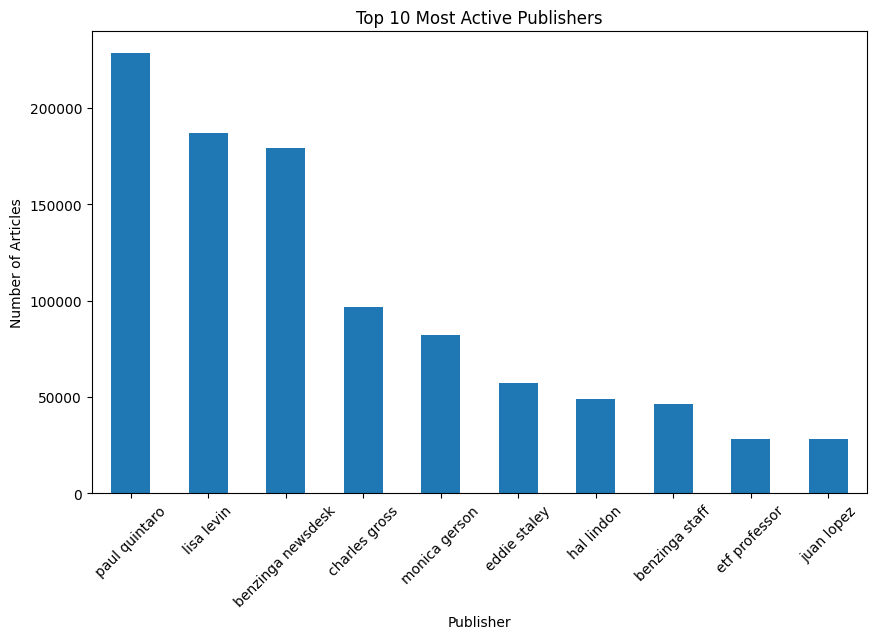

In [9]:
# Count articles per publisher
publisher_counts = df['publisher_clean'].value_counts()

# Display counts
print(publisher_counts.head(10))

# Plot top publishers
plt.figure(figsize=(10,6))
publisher_counts.head(10).plot(kind='bar')

plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.title("Top 10 Most Active Publishers")

plt.xticks(rotation=45)
plt.show()

### Articles per Publisher Summary

- `paul quintaro` published the highest number of articles, contributing over **228,000** articles.
- `lisa levin` and `benzinga newsdesk` were also major contributors, each publishing more than **175,000** articles.
- The distribution shows that article contributions are concentrated among a few highly active publishers.
- Lower-ranked publishers in the top 10 contributed significantly fewer articles, with counts below **50,000**.

In [10]:
print(sorted(df['publisher_clean'].dropna().unique()))
df.head()

['47ertrends', 'Benzinga Staff', 'aakin', 'aaron jackson.ed', 'aaron levitt', 'aarp', 'abe raymond', 'abhi rao', 'abigail field', 'abnnewswire', 'above average odds', 'accointing', 'activist stocks', 'adam gefvert', 'adam parker', 'adam sarhan', 'adam weiner', 'adam@eosdetroit.io', 'alan brochstein', 'alex biles', 'alex cho', 'alex furno', 'alex ivanovs', 'alex oleinic', 'alex roslin', 'alex schiff', 'alex shadunsky', 'alex shek', 'alexander voigt', 'alexis raskin', 'alfidi capital', 'alfredlittle', 'ali berri', 'ali hakim', 'all options on the table with john salters jr.', 'allan farley', 'allie wickman', 'allyson brooks', 'alpha works', 'alpha7trading', 'alphaclone', 'amit nag', 'amy weingarden', 'andre bourque', 'andre gratian', 'andrew aziz', 'andrew efimoff', 'andrew geller', 'andrew moran', 'andrew rosenbaum', 'andrew ward', 'andrew zatlin', 'andrew@tothetick.com', 'andrewhorowitz', 'andy brown', 'andy djordjalian', 'andy pai', 'andy swan', 'andy@andyswan.com', 'angry bear', 'ank

,Unnamed: 0,headline,url,publisher,date,stock,publisher_clean,headline_char_count
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,benzinga insights,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,benzinga insights,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,lisa levin,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,lisa levin,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,vick meyer,87


## Analysis of Publication Dates

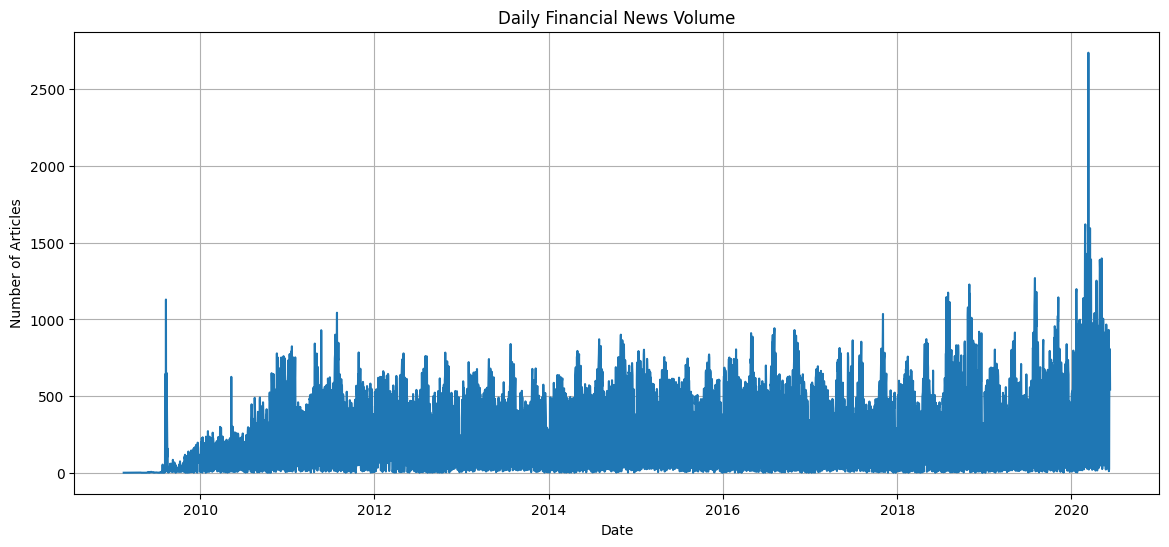

In [ ]:

daily_counts = (
    df.groupby(df['date'].dt.date)
    .size()
)
plt.figure(figsize=(14,6))

daily_counts.plot()

plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.title("Daily Financial News Volume")

plt.grid(True)

plt.show()

### Daily Financial News Volume Summary

- Financial news volume generally increased over time, especially after 2010.
- The dataset shows frequent spikes in article publication, indicating periods of intensified market or financial activity.
- News activity became more volatile and significantly higher between 2018 and 2020.
- The highest publication peak occurred around 2020, exceeding 2,700 articles in a single day.

In [12]:
# top_days = daily_counts.sort_values(ascending=False).head(10)

# print(top_days)
# monthly_counts = (
#     df.groupby(df['date'].dt.to_period('M'))
#     .size()
# )

# monthly_counts.plot(figsize=(12,5))

# plt.title("Monthly News Volume")
# plt.xlabel("Month")
# plt.ylabel("Article Count")

# plt.show()

# Text Analysis (Topic Modeling)
## Common Keywords

In [32]:


stop_words = set(ENGLISH_STOP_WORDS)

def preprocess(text):
    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = text.split()

    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

df['clean_headline'] = df['headline'].astype(str).apply(preprocess)
all_words = " ".join(df['clean_headline']).split()

word_freq = Counter(all_words)

top_keywords = word_freq.most_common(20)

# convert to dataframe
keywords_df = pd.DataFrame(
    top_keywords,
    columns=['Keyword', 'Frequency']
)

print(keywords_df)

       Keyword  Frequency
0       stocks     161868
1          est     140606
2          eps     128929
3       shares     114209
4      reports     108707
5       update      91680
6       market      90880
7     earnings      87185
8        sales      79526
9         week      67669
10   announces      66529
11       price      64232
12         buy      64060
13  downgrades      61942
14     trading      61158
15   benzingas      57985
16      raises      57798
17    upgrades      56804
18      target      54620
19   maintains      52961


### TF-IDF

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X_tfidf = tfidf.fit_transform(df['clean_headline'])

# Average TF-IDF score
scores = X_tfidf.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    'Keyword': tfidf.get_feature_names_out(),
    'TFIDF_Score': scores
})

tfidf_df = tfidf_df.sort_values(
    by='TFIDF_Score',
    ascending=False
)

print(tfidf_df.head(20))

       Keyword  TFIDF_Score
14      stocks     0.095556
13      shares     0.055954
4     earnings     0.054619
11     reports     0.049651
5          eps     0.048863
17      update     0.047752
8       market     0.047605
6          est     0.046856
0    announces     0.041035
19        week     0.038328
12       sales     0.035250
3   downgrades     0.034175
1    benzingas     0.033902
2          buy     0.031055
16     trading     0.030984
9        price     0.028693
18    upgrades     0.028482
10      raises     0.027088
7    maintains     0.024754
15      target     0.022593


## Common Phrases

###  CountVectorizer

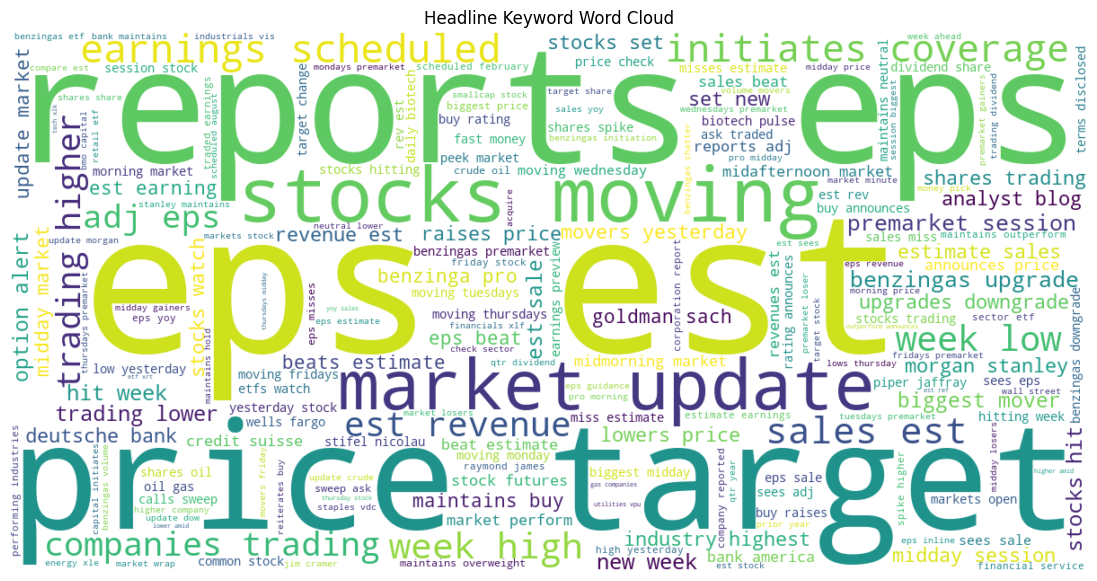

In [31]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['clean_headline'])

bigram_counts = X.toarray().sum(axis=0)

bigrams_df = pd.DataFrame({
    'Bigram': vectorizer.get_feature_names_out(),
    'Frequency': bigram_counts
})

bigrams_df = bigrams_df.sort_values(
    by='Frequency',
    ascending=False
)

# print(bigrams_df)
text = " ".join(df['clean_headline'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title("Headline Keyword Word Cloud")

plt.show()

### Latent Dirichlet Allocation(LDA)

In [34]:
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize text
lda_vectorizer = CountVectorizer(
    stop_words='english',
    max_features=1000
)

X_lda = lda_vectorizer.fit_transform(df['clean_headline'])

# Train LDA
lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda.fit(X_lda)

# Display topics
words = lda_vectorizer.get_feature_names_out()

for idx, topic in enumerate(lda.components_):
    print(f"\nTopic {idx+1}")

    top_words = [
        words[i]
        for i in topic.argsort()[-10:]
    ]

    print(top_words)

KeyboardInterrupt: 

### Common Keywords and Phrases Summary

- The most significant keywords identified using TF-IDF were `stocks`, `shares`, `earnings`, `reports`, and `eps`.
- Recurring financial themes focused heavily on market activity, company performance, analyst actions, and trading updates.
- Terms such as `upgrades`, `downgrades`, `price`, `target`, and `buy` indicate strong coverage of analyst recommendations and stock evaluations.
- Frequent appearance of words like `sales`, `market`, `trading`, and `update` highlights continuous reporting on financial performance and market movements.

# Time Series Analysis of News Volume

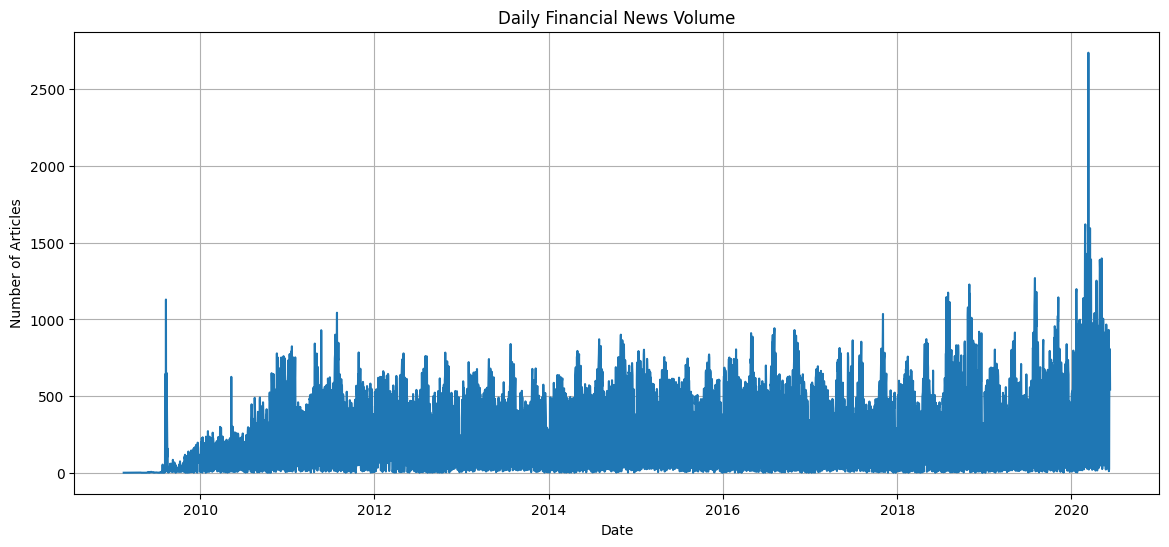

date
2020-03-12    2739
2020-02-28    1620
2020-03-19    1595
2020-02-27    1567
2020-03-06    1428
2020-05-07    1398
2020-03-23    1391
2020-04-29    1389
2020-03-11    1384
2020-04-30    1327
dtype: int64


In [37]:
# -----------------------------
# DAILY PUBLICATION FREQUENCY
# -----------------------------

daily_news = (
    df.groupby(df['date'].dt.date)
    .size()
)

# plot daily news volume
plt.figure(figsize=(14,6))

plt.plot(
    daily_news.index,
    daily_news.values
)

plt.xlabel("Date")
plt.ylabel("Number of Articles")

plt.title("Daily Financial News Volume")

plt.grid(True)

plt.show()
# -----------------------------
# IDENTIFY SPIKES
# -----------------------------

# top publication days
spikes = daily_news.sort_values(
    ascending=False
).head(10)

print(spikes)

## Publishing Time of Day

hour
0     1351472
1          82
2          48
3          27
4          67
5          14
6          57
7          93
8        1469
9        1829
10       2476
11       5033
12       5527
13       5965
14       7669
15       5701
16       5732
17       2710
18       2075
19       1612
20       3939
21       2800
22        704
23        227
dtype: int64


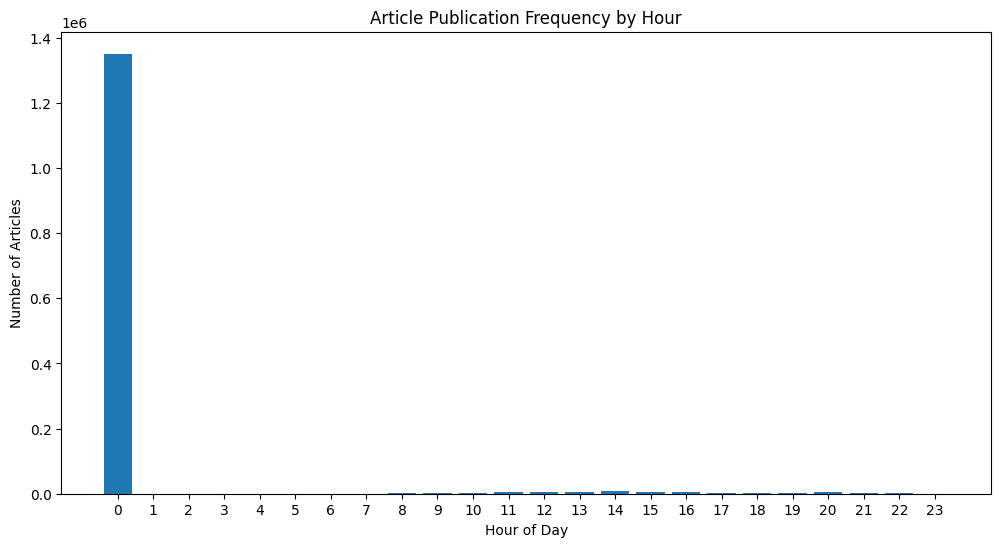

In [39]:
df['hour'] = df['date'].dt.hour

# count publications by hour
hourly_news = (
    df.groupby('hour')
    .size()
)

print(hourly_news)
plt.figure(figsize=(12,6))

plt.bar(
    hourly_news.index,
    hourly_news.values
)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Articles")

plt.title("Article Publication Frequency by Hour")

plt.xticks(range(0,24))

plt.show()

## Heatmap of Publishing Activity

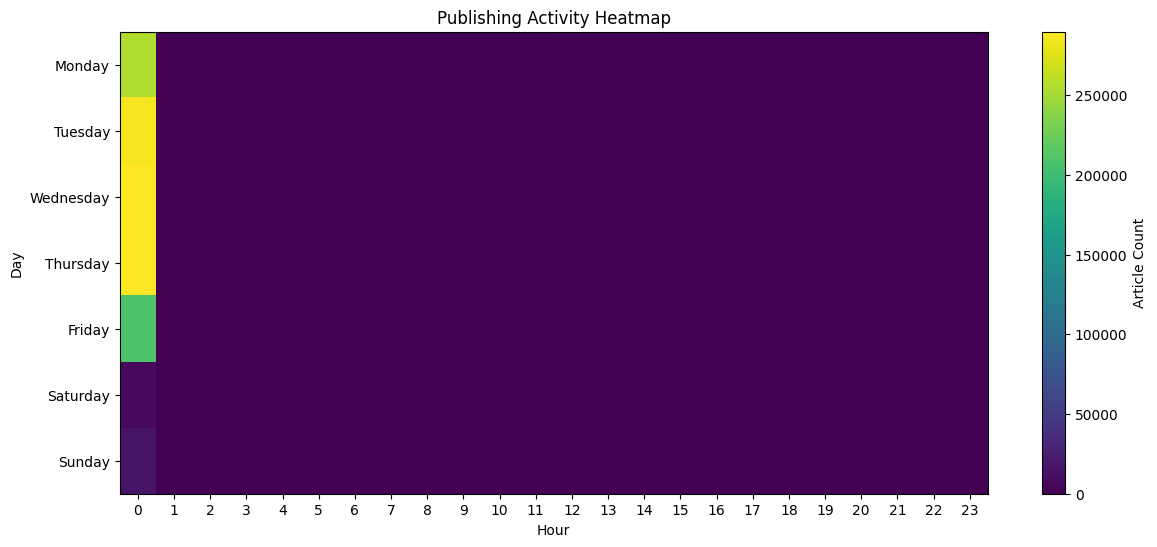

In [40]:
# weekday
df['weekday'] = df['date'].dt.day_name()

# pivot table
heatmap_data = pd.pivot_table(
    df,
    index='weekday',
    columns='hour',
    aggfunc='size',
    fill_value=0
)

# reorder weekdays
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

heatmap_data = heatmap_data.reindex(weekday_order)

# plot heatmap
plt.figure(figsize=(14,6))

plt.imshow(
    heatmap_data,
    aspect='auto'
)

plt.colorbar(label='Article Count')

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.xticks(range(24))

plt.xlabel("Hour")
plt.ylabel("Day")

plt.title("Publishing Activity Heatmap")

plt.show()

### News Publication Trend Summary

- Financial news publication volume increased steadily over time, with noticeably higher activity between 2018 and 2020.
- Several sharp spikes in daily article volume were observed, likely corresponding to major market events, earnings seasons, or periods of heightened market volatility.
- The highest publication peak occurred around 2020, exceeding 2,700 articles in a single day.
- Publishing activity by hour showed an unusually large concentration at hour `0` across all weekdays, particularly on Tuesday through Thursday.
- The heatmap suggests that most articles were recorded around midnight, which may indicate timezone normalization issues, default timestamps, or scheduled batch publishing behavior.

# Publisher Analysis

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64


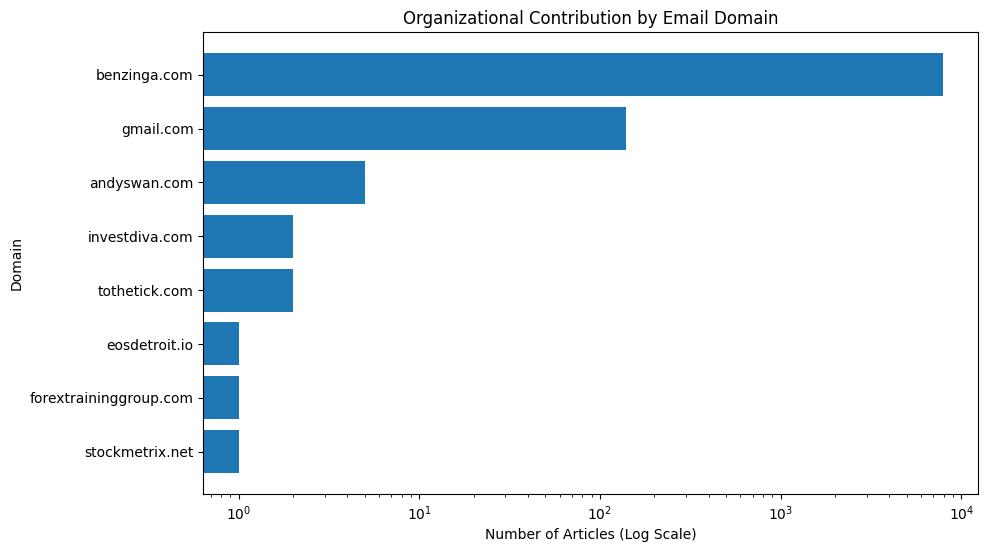

In [42]:
# extract email-like publishers
email_publishers = df[
    df['publisher'].astype(str).str.contains('@', na=False)
].copy()


# extract domain names
email_publishers['domain'] = (
    email_publishers['publisher']
    .str.extract(r'@([\w\.-]+)')
)

# top domains
top_domains = (
    email_publishers['domain']
    .value_counts()
    .head(10)
)

print(top_domains)


# -----------------------------
# VISUALIZE DOMAIN CONTRIBUTIONS
# -----------------------------

# plot
plt.figure(figsize=(10,6))

plt.barh(
    top_domains.index,
    top_domains.values
)

# logarithmic scale
plt.xscale('log')

plt.xlabel("Number of Articles (Log Scale)")
plt.ylabel("Domain")

plt.title("Organizational Contribution by Email Domain")

plt.gca().invert_yaxis()

plt.show()

### Organizational Contribution Pattern Summary

- `benzinga.com` overwhelmingly dominated organizational contributions, accounting for the vast majority of email-based publisher entries.
- Only a small number of articles were associated with other domains such as `gmail.com`, `andyswan.com`, and `investdiva.com`.
- The distribution of domain contributions was highly imbalanced, indicating that most organizational publishing activity originated from a single primary source.